In [1]:
print('hello')
import pandas as pd
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.pyplot import rc_context
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import scanpy as sc
from matplotlib import rc_context
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap

h5ad_file = "/home/catherine/phd/projects/termites/data/znev/combined_no_norm_clustered.h5ad"
adata = sc.read_h5ad(h5ad_file)



hello


In [2]:
cell_type_column = 'paper_cell_type_annotation'  
cell_types = adata.obs[cell_type_column].unique()

In [3]:
# first find DE genes of castes compared to workers in each cell type. (exc where they aren't enough cells in either worker of the caste )
castes = ["soldier", "queen", "king"]

In [4]:
caste_ct_de_results = {}

for cell_type in cell_types:
    print(f"Processing cell type: {cell_type}")
    adata_cell = adata[adata.obs[cell_type_column] == cell_type]
    #castes = adata_cell.obs["caste"].unique()
    de_results = {}

    print(f"  Caste counts for {cell_type}:")
    print(adata_cell.obs["caste"].value_counts())



    for caste in castes:
        # compare this caste vs workers ONLY
        adata_sub = adata_cell[adata_cell.obs["caste"].isin([caste, "worker"])].copy()
        n_caste = (adata_sub.obs['caste'] == caste).sum()
        n_worker = (adata_sub.obs['caste'] == 'worker').sum()

        if n_caste >= 2 and n_worker >= 2:
            adata_sub.obs["comparison_group"] = ["target" if c == caste else "other"
                                                for c in adata_sub.obs["caste"]]
            sc.tl.rank_genes_groups(adata_sub, groupby="comparison_group", method="wilcoxon")
            tmp = adata_sub.uns["rank_genes_groups"]

            deg = pd.DataFrame(
                index=[x[1] for x in tmp["names"]],
                data={
                    "score": [x[1] for x in tmp["scores"]],
                    "pval": [x[1] for x in tmp["pvals"]],
                    "pval_adj": [x[1] for x in tmp["pvals_adj"]],
                    "logFC": [x[1] for x in tmp["logfoldchanges"]],
                },
            )

            de_results[caste] = deg

    caste_ct_de_results[cell_type] = de_results


Processing cell type: T5
  Caste counts for T5:
caste
worker     289
queen      219
soldier    141
king        57
Name: count, dtype: int64
Processing cell type: epithelial
  Caste counts for epithelial:
caste
worker     1544
soldier     669
queen       496
king        337
Name: count, dtype: int64
Processing cell type: stem cell
  Caste counts for stem cell:
caste
queen      1144
worker      838
soldier     387
king        287
Name: count, dtype: int64
Processing cell type: sensory neuron
  Caste counts for sensory neuron:
caste
worker     440
soldier    224
queen      103
king        57
Name: count, dtype: int64
Processing cell type: fat cell
  Caste counts for fat cell:
caste
queen      1105
worker      543
soldier     344
king        226
Name: count, dtype: int64
Processing cell type: T3
  Caste counts for T3:
caste
worker     576
soldier    291
queen      228
king       139
Name: count, dtype: int64
Processing cell type: glial cell
  Caste counts for glial cell:
caste
worker     3

In [5]:
# cell type DE 
cell_types = adata.obs[cell_type_column].unique()
celltype_only_de_results = {}

for cell_type in cell_types:

    is_target = adata.obs[cell_type_column] == cell_type
    is_other = adata.obs[cell_type_column] != cell_type

    if is_target.sum() < 2 or is_other.sum() < 2:
        print(f"skipping {cell_type}: not enough cells in one of the groups.")
        continue

    adata_sub = adata.copy()
    adata_sub.obs["comparison_group"] = ["target" if x == cell_type else "other" for x in adata_sub.obs[cell_type_column]]

    sc.tl.rank_genes_groups(adata_sub, groupby="comparison_group", method="wilcoxon")
    tmp = adata_sub.uns["rank_genes_groups"]

    deg = pd.DataFrame(
        index=[x[1] for x in tmp["names"]],
        data={
            "score": [x[1] for x in tmp["scores"]],
            "pval": [x[1] for x in tmp["pvals"]],
            "pval_adj": [x[1] for x in tmp["pvals_adj"]],
            "logFC": [x[1] for x in tmp["logfoldchanges"]],
        },
    )

    celltype_only_de_results[cell_type] = deg


fat cell and queen maker: Znev00000502, pdgy
fat cell and queen maker: Znev00012023, Ugp
fat cell and queen maker: Znev00011220, P5cr-2


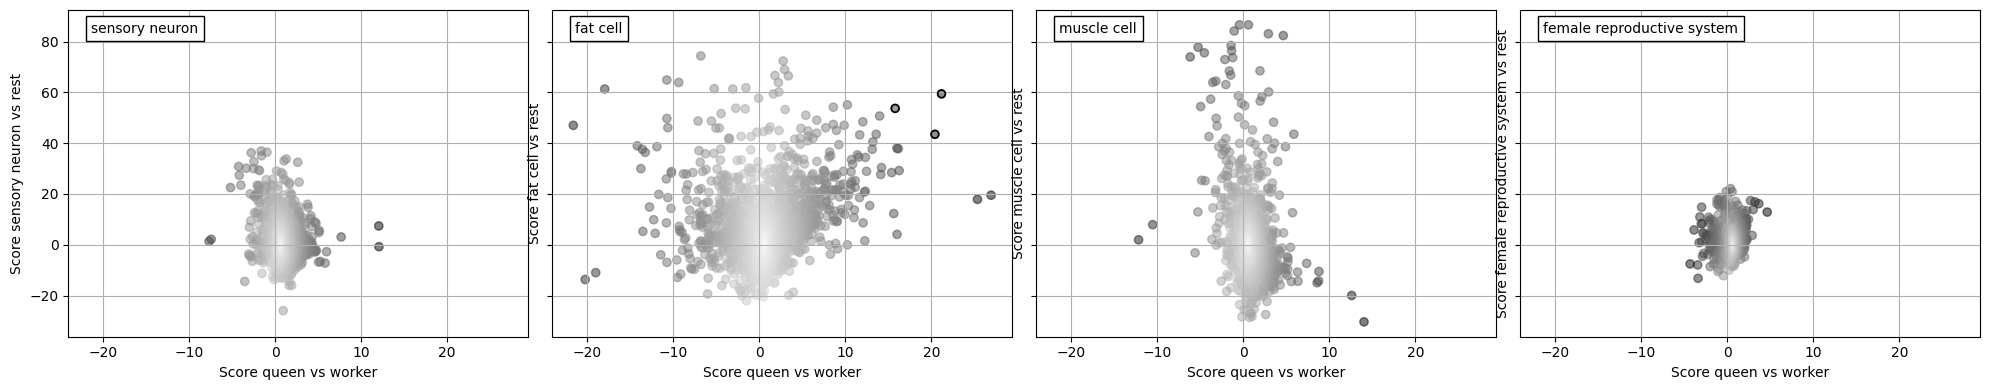

In [6]:
#find genes that lok interesting to highlight oz    n plot

# I am taking 

cell_type_to_plot = ['sensory neuron', 'fat cell', 'muscle cell', 'female reproductive system']

# all castes (not balanced), cell type vs rest (nothing balanced)
celltype_only_de_results




%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

column = "score"
cell_type = "sensory neuron"
caste = "queen"

fig, axs = plt.subplots(1, 4, figsize=(20, 4), sharex=True, sharey=True)
axs = axs.ravel()
for i, (ax, cell_type) in enumerate(zip(axs, cell_type_to_plot)):
    x = caste_ct_de_results[cell_type][caste][column]
    y = celltype_only_de_results[cell_type][column]
    r = np.sqrt(((10 *x)**2) + (y**2))
    cvalues = r.loc[x.index].values
    ax.scatter(x, y.loc[x.index], alpha=0.5, zorder=-1, c=np.sqrt(cvalues), cmap="Greys")
    #if i == 0:
    #    sns.kdeplot(x=x, y=y.loc[x.index], ax=ax, levels=30)
    ax.set_xlabel(f"{column.capitalize()} {caste} vs worker")
    ax.set_ylabel(f"{column.capitalize()} {cell_type} vs rest")
    #ax.set_title(cell_type)
    ax.text(0.05, 0.93, cell_type, transform=ax.transAxes, bbox={"facecolor": "white", "edgecolor": "black", "linewidth": 1})
    ax.grid(True)
    top_genes = r.nlargest(1000).index
    for gene in top_genes:
        dmel_homolog = adata.var.loc[gene, "dmel_gene_symbol"]
        label = gene
        if isinstance(dmel_homolog, str):
            label += f", {dmel_homolog}"
        if ((x.loc[gene]) > 15) & ((y.loc[gene]) > 40):
            print(f"{cell_type} and {caste} maker: {label}")
            #ax.text(x.loc[gene], y.loc[gene], label, ha="center", va="center")
            ax.scatter(x.loc[gene], y.loc[gene],
                   s=30, facecolors="none", edgecolors="black",
                   linewidths=1.2, zorder=3)


fig.tight_layout(h_pad=0, w_pad=0)
plt.show()



In [7]:
gene_dict = {
    'female reproductive system': ['Znev00000977', 'Znev00002314', 'Znev00010359', 'Znev00014135'],

    'fat cell': ['Znev00012632', 'Znev00004477', 'Znev00014136', 'Znev00000502', 'Znev00012023', 'Znev00011220'],
    'muscle cell': ['Znev00001420', 'Znev00013934', 'Znev00013115', 'Znev00010825', 'Znev00000677'],
    
    'sensory neuron': ['Znev00012349', 'Znev00010122', 'Znev00003945', 'Znev00013171'],

}

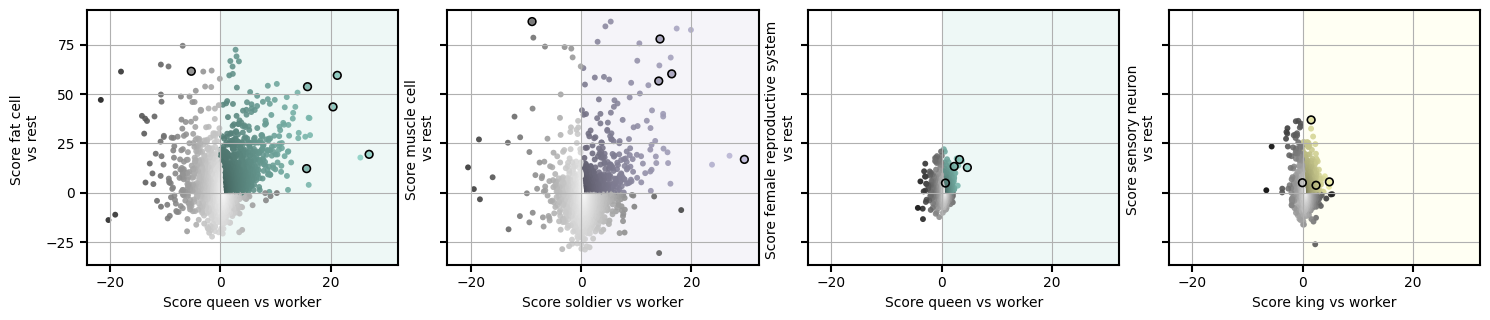

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

# 🔥 Toggle gene labels on/off
SHOW_LABELS = False

cell_type_to_plot = ['fat cell', 'muscle cell', 
                     'female reproductive system', 'sensory neuron']

caste_for_celltype = {
    'female reproductive system': 'queen',
    'fat cell': 'queen',
    'muscle cell': 'soldier',
    'sensory neuron': 'king',
}

castes = ["queen", "king", "soldier", "worker"]
palette = sns.color_palette("Set3", n_colors=len(castes))
palette_dict = dict(zip(castes, palette))

column = "score"

def darkened_cmap(rgb, dark_factor=0.4):
    r, g, b = rgb
    dark_rgb = tuple(np.array([r, g, b]) * dark_factor)
    return LinearSegmentedColormap.from_list(
        "dark_to_hue",
        [dark_rgb, (r, g, b)],
        N=256
    )

# ---- compute global x/y limits ----
all_x, all_y = [], []

for ct in cell_type_to_plot:
    caste = caste_for_celltype[ct]
    x_ct = caste_ct_de_results[ct][caste][column]
    y_ct = celltype_only_de_results[ct][column].loc[x_ct.index]
    all_x.append(x_ct.values)
    all_y.append(y_ct.values)

all_x = np.concatenate(all_x)
all_y = np.concatenate(all_y)

xmin, xmax = np.nanmin(all_x), np.nanmax(all_x)
ymin, ymax = np.nanmin(all_y), np.nanmax(all_y)

xpad = 0.05 * (xmax - xmin if xmax > xmin else 1.0)
ypad = 0.05 * (ymax - ymin if ymax > ymin else 1.0)

xlim = (xmin - xpad, xmax + xpad)
ylim = (ymin - ypad, ymax + ypad)

# ---- plot ----
fig, axs = plt.subplots(1, 4, figsize=(15, 3.3), sharex=True, sharey=True)
axs = axs.ravel()

for ax, ct in zip(axs, cell_type_to_plot):

    caste = caste_for_celltype[ct]

    x = caste_ct_de_results[ct][caste][column]
    y = celltype_only_de_results[ct][column]
    y_aligned = y.loc[x.index]

    # r metric → grayscale
    r = np.sqrt(((10 * x)**2) + (y_aligned**2))
    r_sqrt = np.sqrt(r)
    rnorm = (r_sqrt - np.nanmin(r_sqrt)) / (np.nanmax(r_sqrt) - np.nanmin(r_sqrt) + 1e-12)

    gray_colors = plt.get_cmap("Greys")(rnorm.values)
    caste_cmap = darkened_cmap(palette_dict[caste], dark_factor=0.4)

    mask = (x > 0) & (y_aligned > 0)

    final_colors = gray_colors.copy()
    final_colors[mask.values] = caste_cmap(rnorm.values[mask.values])

    ax.scatter(
        x, y_aligned,
        c=final_colors,
        s=18,
        edgecolors="none",
        alpha=0.9,
        zorder=1
    )

    # Limits + background shading
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)

    if xlim[1] > 0:
        ax.axvspan(
            0, xlim[1],
            facecolor=palette_dict[caste],
            alpha=0.15,
            zorder=0,
            ymin=0.0, ymax=1.0,
            transform=ax.get_xaxis_transform()
        )

    ax.set_xlabel(f"{column.capitalize()} {caste} vs worker")
    ax.set_ylabel(f"{column.capitalize()} {ct} \nvs rest")

    ax.grid(True, zorder=-5)

    # ---- Thicker plot outline (1.5) ----
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
        spine.set_color("black")

    # ---- Thicker ticks (1.5) ----
    ax.tick_params(axis='both', which='both',
                   width=1.5,
                   length=5)

    # ---- Outline highlighted genes ----
    genes_to_label = [
        g for g in gene_dict.get(ct, [])
        if (g in x.index) and (g in y.index)
    ]

    if genes_to_label:
        ax.scatter(
            x.loc[genes_to_label],
            y_aligned.loc[genes_to_label],
            s=30,
            facecolors="none",
            edgecolors="black",
            linewidths=1.2,
            zorder=3
        )

        if SHOW_LABELS:
            for gene in genes_to_label:
                dmel = (
                    adata.var.loc[gene, "dmel_gene_symbol"]
                    if gene in adata.var.index else np.nan
                )
                label = gene if not isinstance(dmel, str) else f"{gene}, {dmel}"

                ax.annotate(
                    label,
                    (x.loc[gene], y_aligned.loc[gene]),
                    xytext=(0, 0),
                    textcoords="offset points",
                    ha="center",
                    va="center",
                    fontsize=8,
                    zorder=4,
                    clip_on=False
                )

plt.rcParams.update({
    'xtick.labelsize': 15,
    'ytick.labelsize': 15
})

fig.tight_layout(h_pad=0, w_pad=0.5)
plt.show()

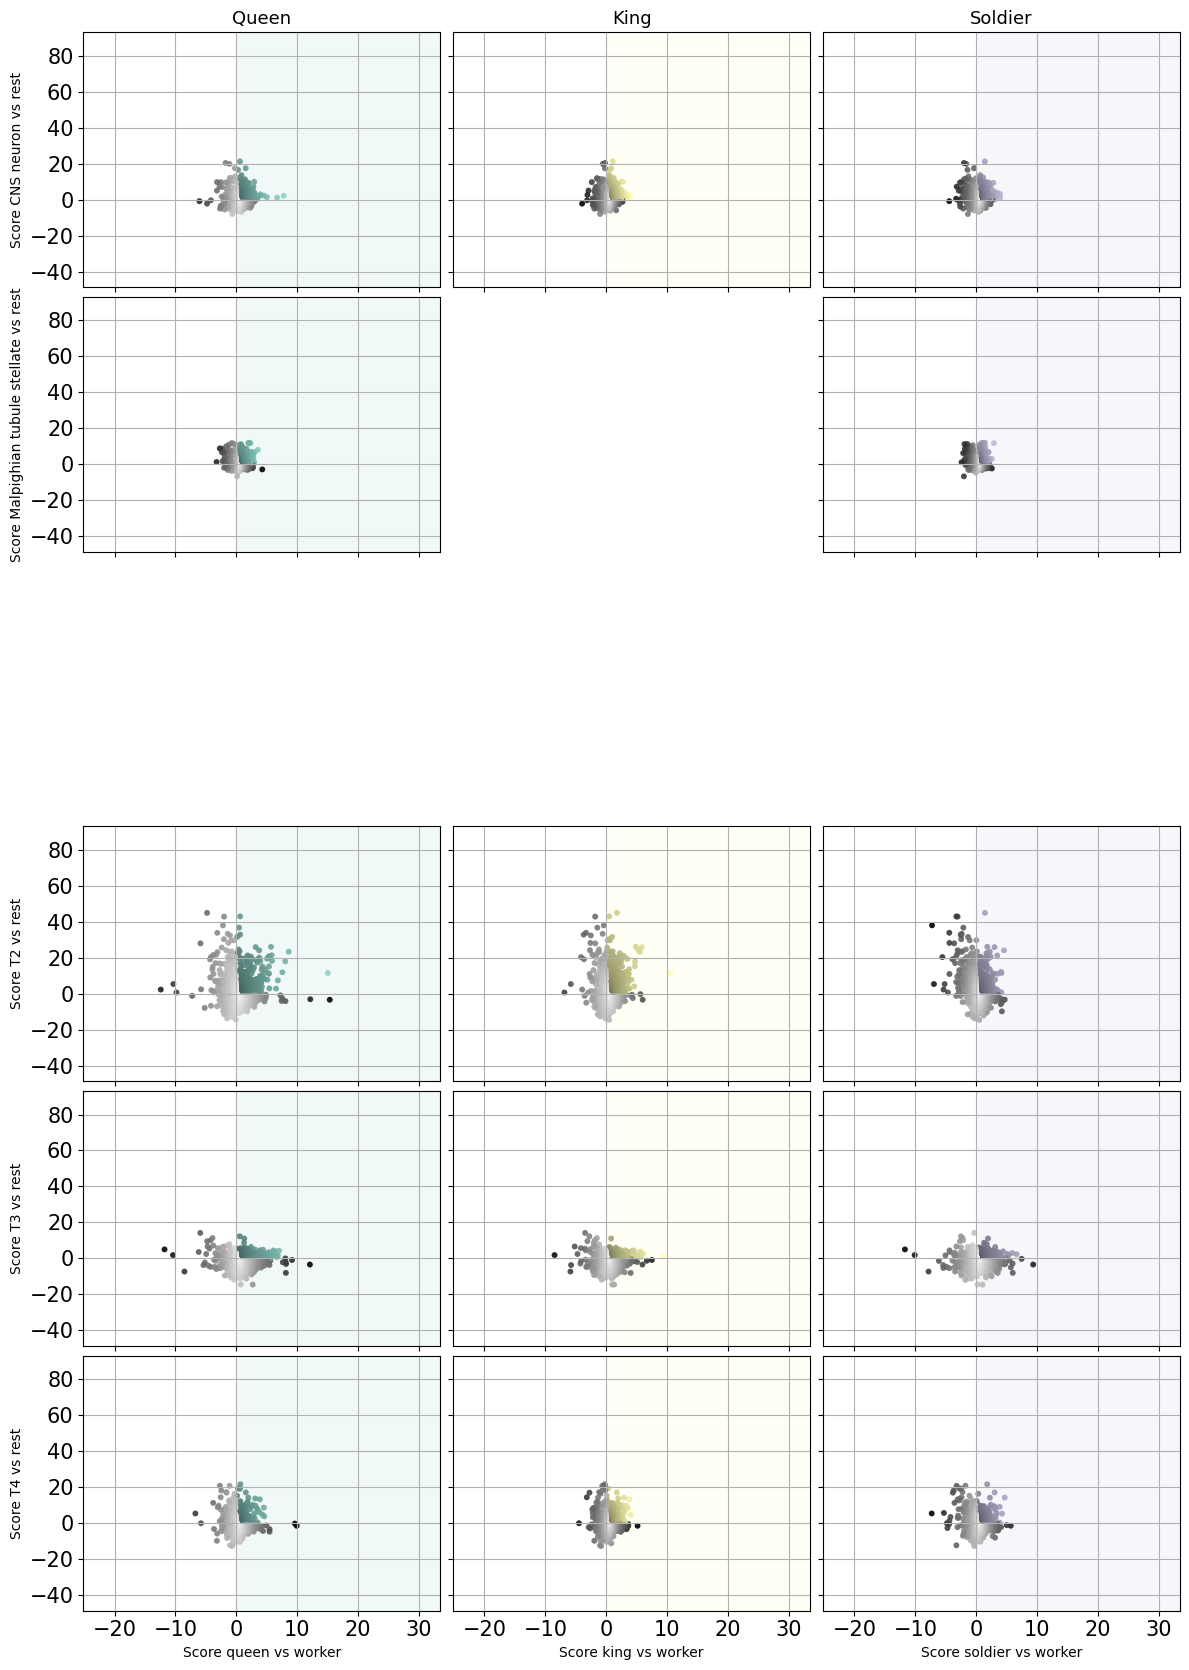

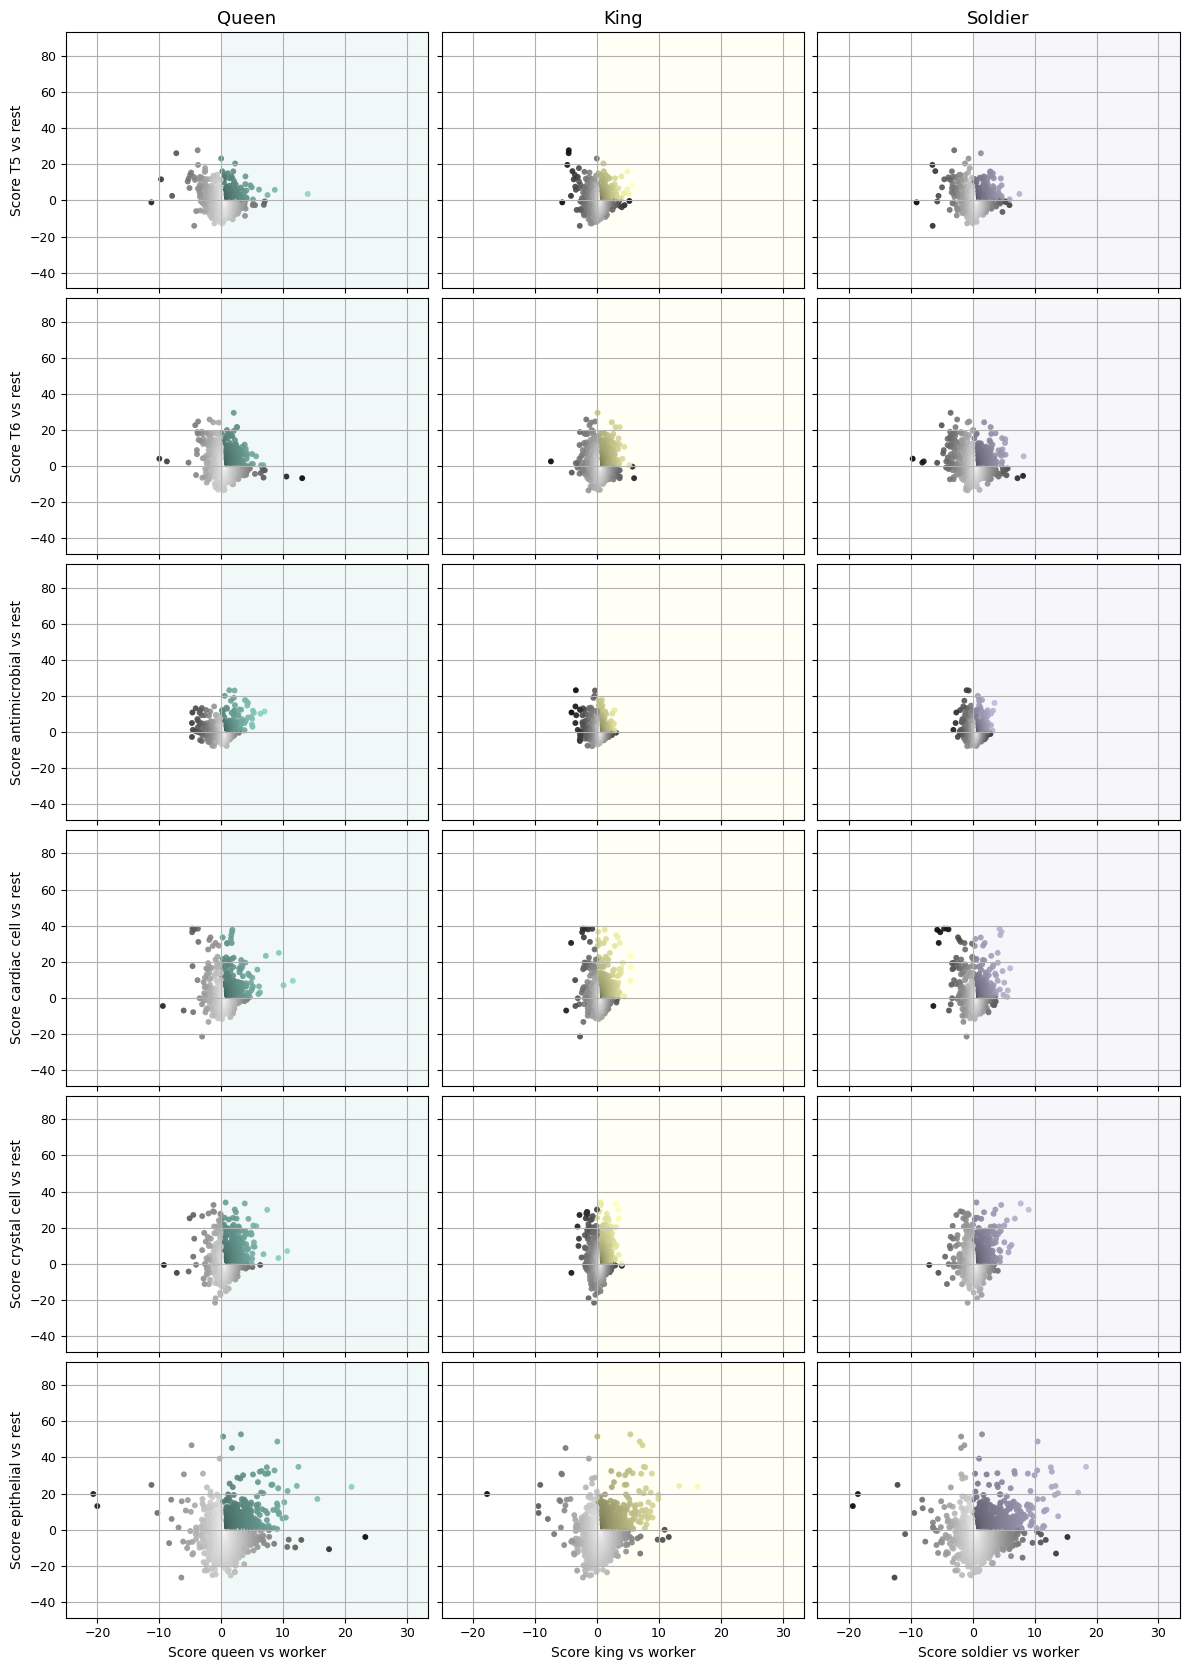

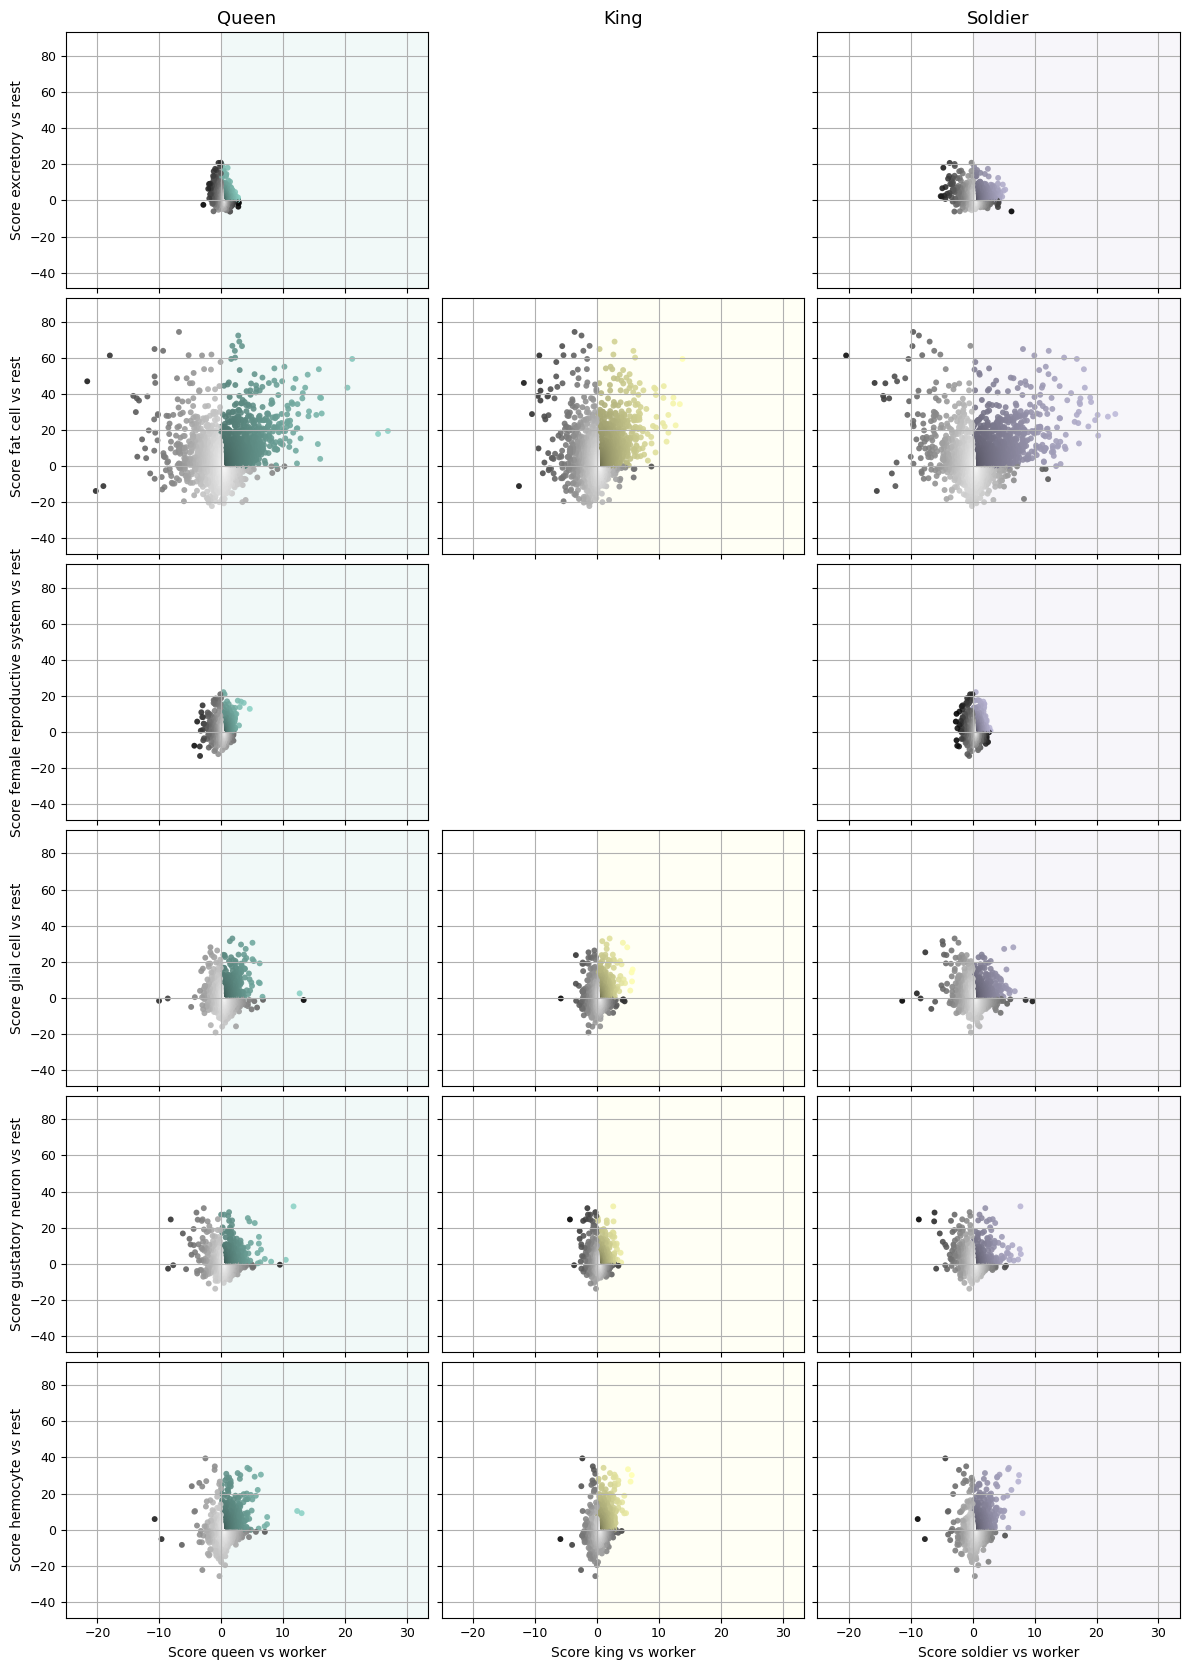

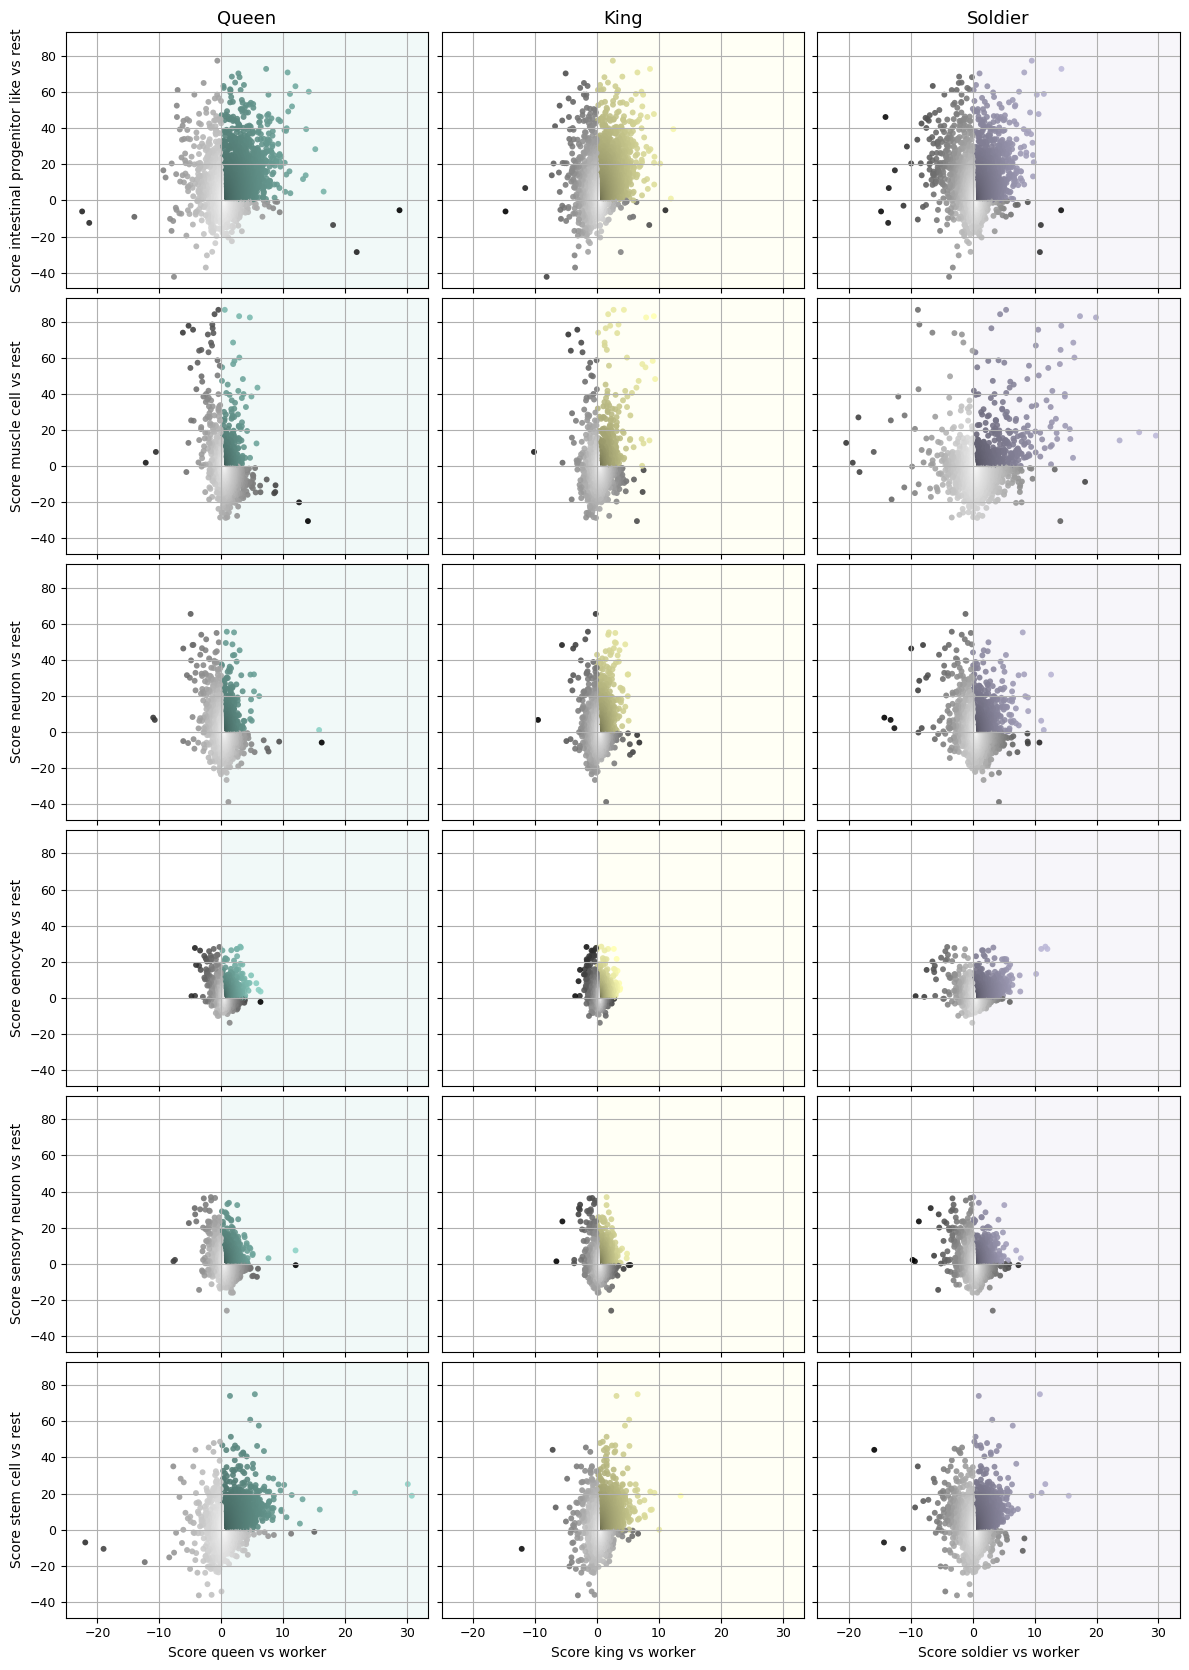

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# ---------------- CONFIG ----------------
castes = ["queen", "king", "soldier"]   # worker omitted
palette = sns.color_palette("Set3", n_colors=len(castes))
palette_dict = dict(zip(castes, palette))
column = "score"
batch_size = 6            # ← six cell types per figure
consistent_limits = True  # True: same limits across all figures; False: per-figure limits
save_figs = False
save_prefix = "ct_grid_page"

def darkened_cmap(rgb, dark_factor=0.4):
    r, g, b = rgb
    dark_rgb = tuple(np.array([r, g, b]) * dark_factor)
    return LinearSegmentedColormap.from_list("dark_to_hue", [dark_rgb, (r, g, b)], N=256)

# Cell types present in both dicts
all_cell_types = sorted(set(caste_ct_de_results.keys()) & set(celltype_only_de_results.keys()))

def compute_limits(ct_list):
    xvals, yvals = [], []
    for ct in ct_list:
        if ct not in celltype_only_de_results:
            continue
        y_ct = celltype_only_de_results[ct][column]
        for caste in castes:
            if ct not in caste_ct_de_results or caste not in caste_ct_de_results[ct]:
                continue
            x_ct = caste_ct_de_results[ct][caste][column]
            if x_ct is None or x_ct.empty:
                continue
            y_aligned = y_ct.reindex(x_ct.index).dropna()
            if y_aligned.empty:
                continue
            x_aligned = x_ct.loc[y_aligned.index]
            if x_aligned.empty:
                continue
            xvals.append(x_aligned.values)
            yvals.append(y_aligned.values)
    if not xvals:
        return (-1, 1), (-1, 1)
    xvals = np.concatenate(xvals); yvals = np.concatenate(yvals)
    xmin, xmax = np.nanmin(xvals), np.nanmax(xvals)
    ymin, ymax = np.nanmin(yvals), np.nanmax(yvals)
    xpad = 0.05 * (xmax - xmin if xmax > xmin else 1.0)
    ypad = 0.05 * (ymax - ymin if ymax > ymin else 1.0)
    return (xmin - xpad, xmax + xpad), (ymin - ypad, ymax + ypad)

global_xlim, global_ylim = compute_limits(all_cell_types) if consistent_limits else (None, None)

def chunks(lst, n):
    for i in range(0, len(lst), n):
        yield lst[i:i+n]

for page_idx, ct_batch in enumerate(chunks(all_cell_types, batch_size), start=1):
    xlim, ylim = (global_xlim, global_ylim) if consistent_limits else compute_limits(ct_batch)

    n_rows = len(ct_batch)
    n_cols = len(castes)
    # Slightly shorter per-row height so 6 rows fit nicely
    fig, axs = plt.subplots(n_rows, n_cols, figsize=(4.0 * n_cols, 2.8 * n_rows), sharex=True, sharey=True)
    axs = np.atleast_2d(axs)

    for j, caste in enumerate(castes):
        axs[0, j].set_title(caste.capitalize(), fontsize=13, pad=6)

    for i, ct in enumerate(ct_batch):
        y_ct = celltype_only_de_results[ct][column]
        for j, caste in enumerate(castes):
            ax = axs[i, j]

            if (ct not in caste_ct_de_results) or (caste not in caste_ct_de_results[ct]):
                ax.axis("off"); continue
            x = caste_ct_de_results[ct][caste][column]
            if x is None or x.empty:
                ax.axis("off"); continue

            y_aligned = y_ct.reindex(x.index).dropna()
            if y_aligned.empty:
                ax.axis("off"); continue

            x_aligned = x.loc[y_aligned.index]
            if x_aligned.empty:
                ax.axis("off"); continue

            # r metric → grayscale base; caste tint in +/+ quadrant
            r = np.sqrt(((10 * x_aligned)**2) + (y_aligned**2))
            r_sqrt = np.sqrt(r)
            rnorm = (r_sqrt - np.nanmin(r_sqrt)) / (np.nanmax(r_sqrt) - np.nanmin(r_sqrt) + 1e-12)

            gray_colors = plt.get_cmap("Greys")(rnorm.values)
            caste_cmap = darkened_cmap(palette_dict[caste], dark_factor=0.4)

            mask = (x_aligned > 0) & (y_aligned > 0)
            final_colors = gray_colors.copy()
            final_colors[mask.values] = caste_cmap(rnorm.values[mask.values])

            ax.scatter(x_aligned, y_aligned, c=final_colors, s=18, edgecolors="none", alpha=0.9, zorder=1)

            ax.set_xlim(*xlim); ax.set_ylim(*ylim)
            if xlim[1] > 0:
                ax.axvspan(0, xlim[1], facecolor=palette_dict[caste], alpha=0.12,
                           zorder=0, ymin=0.0, ymax=1.0, transform=ax.get_xaxis_transform())

            if i == n_rows - 1:
                ax.set_xlabel(f"{column.capitalize()} {caste} vs worker", fontsize=10)
            if j == 0:
                ax.set_ylabel(f"{column.capitalize()} {ct} vs rest", fontsize=10)

            ax.grid(True, zorder=-5)

    plt.rcParams.update({'xtick.labelsize': 9, 'ytick.labelsize': 9})
    fig.tight_layout(h_pad=0.35, w_pad=0.6)

    if save_figs:
        fname = f"{save_prefix}_{page_idx:02d}.png"
        fig.savefig(fname, dpi=300, bbox_inches="tight")
        print(f"Saved {fname}")

    plt.show()


fat cell
"Znev00008624",
"Znev00000949",
"Znev00007246",
"Znev00008221",
muscle cell
"Znev00013934",
"Znev00009858",
"Znev00013119",


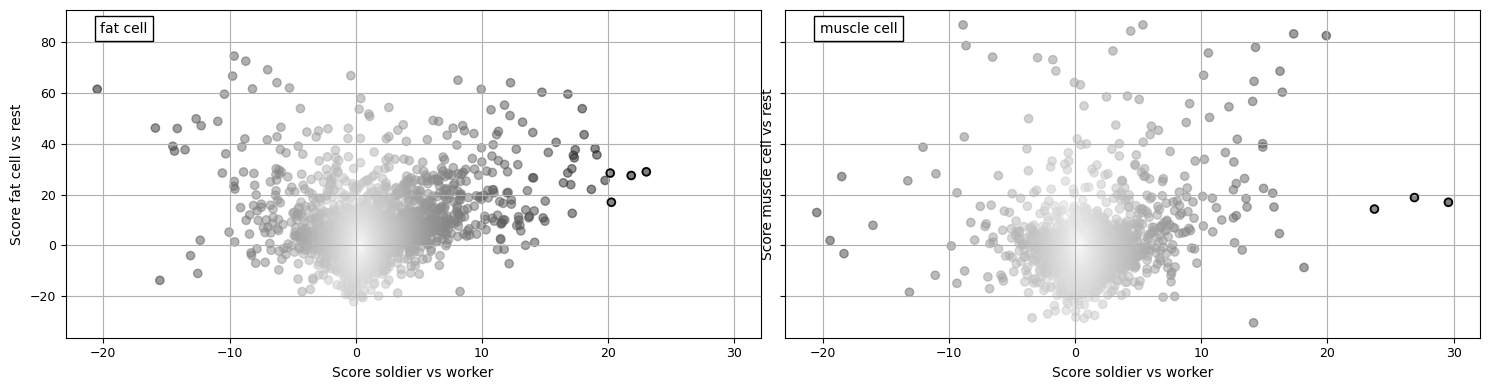

In [10]:
#find genes that lok interesting to highlight on plot

# I am taking 

cell_type_to_plot = ['fat cell', 'muscle cell']

# all castes (not balanced), cell type vs rest (nothing balanced)
celltype_only_de_results




%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

column = "score"
cell_type = "sensory neuron"
caste = "soldier"

fig, axs = plt.subplots(1, 2, figsize=(15, 4), sharex=True, sharey=True)
axs = axs.ravel()
for i, (ax, cell_type) in enumerate(zip(axs, cell_type_to_plot)):
    print(f"{cell_type}")
    x = caste_ct_de_results[cell_type][caste][column]
    y = celltype_only_de_results[cell_type][column]
    r = np.sqrt(((10 *x)**2) + (y**2))
    cvalues = r.loc[x.index].values
    ax.scatter(x, y.loc[x.index], alpha=0.5, zorder=-1, c=np.sqrt(cvalues), cmap="Greys")
    #if i == 0:
    #    sns.kdeplot(x=x, y=y.loc[x.index], ax=ax, levels=30)
    ax.set_xlabel(f"{column.capitalize()} {caste} vs worker")
    ax.set_ylabel(f"{column.capitalize()} {cell_type} vs rest")
    #ax.set_title(cell_type)
    ax.text(0.05, 0.93, cell_type, transform=ax.transAxes, bbox={"facecolor": "white", "edgecolor": "black", "linewidth": 1})
    ax.grid(True)
    top_genes = r.nlargest(1000).index
    for gene in top_genes:
        dmel_homolog = adata.var.loc[gene, "dmel_gene_symbol"]
        label = gene
        if isinstance(dmel_homolog, str):
            label += f", {dmel_homolog}"
        if ((x.loc[gene]) > 20) & ((y.loc[gene]) > 1):
            #print(f"{cell_type} and {caste} maker: {label}")
            print(f"\"{gene}\",")
            #ax.text(x.loc[gene], y.loc[gene], label, ha="center", va="center")
            ax.scatter(x.loc[gene], y.loc[gene],
                   s=30, facecolors="none", edgecolors="black",
                   linewidths=1.2, zorder=3)


fig.tight_layout(h_pad=0, w_pad=0)
plt.show()



fat cell and soldier downregualted: Znev00000159, FASN1
fat cell and soldier downregualted: Znev00002714, mino
fat cell and soldier downregualted: Znev00008335, Mondo
fat cell and soldier downregualted: Znev00006209
fat cell and soldier downregualted: Znev00004646, Cyp305a1
fat cell and soldier downregualted: Znev00009177, Desat1
fat cell and soldier downregualted: Znev00004341, Fili
fat cell and soldier downregualted: Znev00007094, emp
fat cell and soldier downregualted: Znev00014163
fat cell and soldier downregualted: Znev00005980, Apoltp
fat cell and soldier downregualted: Znev00005781, Hnf4
fat cell and soldier downregualted: Znev00013818, Rbfox1
fat cell and soldier downregualted: Znev00010655
fat cell and soldier downregualted: Znev00005648, apolpp
fat cell and soldier downregualted: Znev00010252, AcCoAS
fat cell and soldier downregualted: Znev00008710, Pxd
fat cell and soldier downregualted: Znev00012632, Apoltp
fat cell and soldier downregualted: Znev00009743, unc-5
fat cell an

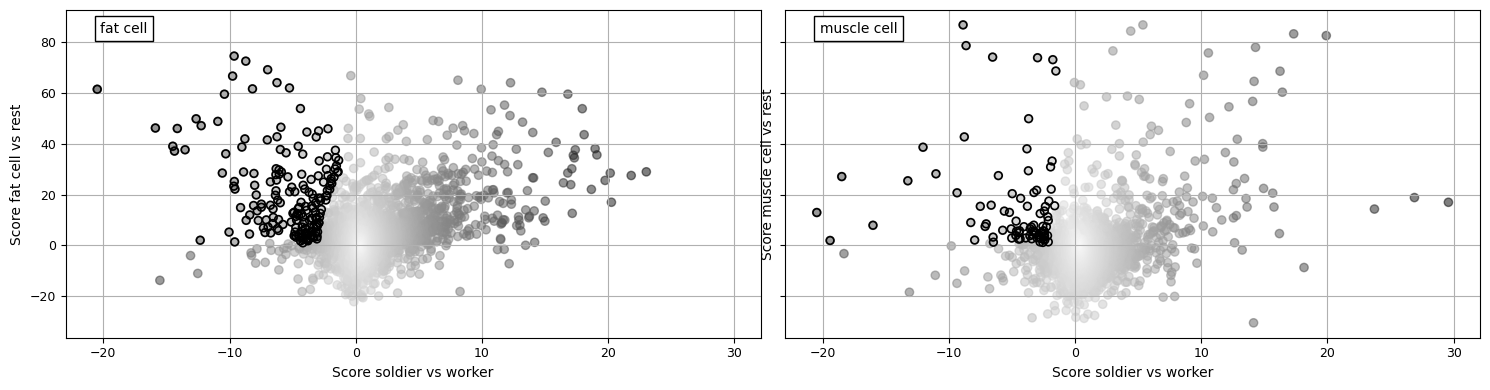

In [11]:
#find genes that lok interesting to highlight on plot

# I am taking 

cell_type_to_plot = ['fat cell', 'muscle cell']

# all castes (not balanced), cell type vs rest (nothing balanced)
celltype_only_de_results




%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

column = "score"
cell_type = "sensory neuron"
caste = "soldier"

fig, axs = plt.subplots(1, 2, figsize=(15, 4), sharex=True, sharey=True)
axs = axs.ravel()
for i, (ax, cell_type) in enumerate(zip(axs, cell_type_to_plot)):
    x = caste_ct_de_results[cell_type][caste][column]
    y = celltype_only_de_results[cell_type][column]
    r = np.sqrt(((10 *x)**2) + (y**2))
    cvalues = r.loc[x.index].values
    ax.scatter(x, y.loc[x.index], alpha=0.5, zorder=-1, c=np.sqrt(cvalues), cmap="Greys")
    #if i == 0:
    #    sns.kdeplot(x=x, y=y.loc[x.index], ax=ax, levels=30)
    ax.set_xlabel(f"{column.capitalize()} {caste} vs worker")
    ax.set_ylabel(f"{column.capitalize()} {cell_type} vs rest")
    #ax.set_title(cell_type)
    ax.text(0.05, 0.93, cell_type, transform=ax.transAxes, bbox={"facecolor": "white", "edgecolor": "black", "linewidth": 1})
    ax.grid(True)
    top_genes = r.nlargest(1000).index
    for gene in top_genes:
        dmel_homolog = adata.var.loc[gene, "dmel_gene_symbol"]
        label = gene
        if isinstance(dmel_homolog, str):
            label += f", {dmel_homolog}"
        if ((x.loc[gene]) < -1) & ((y.loc[gene]) > 1):
            print(f"{cell_type} and {caste} downregualted: {label}")
            #ax.text(x.loc[gene], y.loc[gene], label, ha="center", va="center")
            ax.scatter(x.loc[gene], y.loc[gene],
                   s=30, facecolors="none", edgecolors="black",
                   linewidths=1.2, zorder=3)


fig.tight_layout(h_pad=0, w_pad=0)
plt.show()



In [12]:
contraction_regulation = [
        "Znev00013934",  # TpnC47D
        "Znev00009858",  # TpnC41C
        "Znev00007256",  # up (TnI)
        "Znev00013115",  # Tm2
        "Znev00000677",  # Mlc1
        "Znev00001619",  # Mlc2
        "Znev00005037",  # Strn-Mlck
    ]

calcium_handling_excitation_contraction = [
        "Znev00010825",  # SERCA
        "Znev00013325",  # PMCA
        "Znev00013233",  # Ca-alpha1D (L-type)
        "Znev00013761",  # Orai (SOCE)
        "Znev00007718",  # Piezo
        "Znev00012193",  # CaMKII
        "Znev00013705",  # Stacl (triad)
        "Znev00007995",  # Ca-beta (VGCC beta)
    ]

top_genes_plot = [
    "Znev00013934",
"Znev00009858",

]

genes_fat_top = ['Znev00014136',
 'Znev00014135',
 'Znev00013391',
 'Znev00005601',
 'Znev00005602',
 'Znev00010452',
 'Znev00006453',
 'Znev00010248',
 'Znev00013025',
 'Znev00005900',
 'Znev00000949',
 'Znev00008624',
 'Znev00008221',
 'Znev00002009',
 'Znev00013545',
 'Znev00007094',
 'Znev00000159',
 'Znev00008335',
 'Znev00009177',
 'Znev00002714',
 'Znev00012618']

fat_marker = ['Znev00012632', 'Znev00004477']

In [13]:
genes_muscle_top = ['Znev00002365',
 'Znev00013254',
 'Znev00005077',
 'Znev00003971',
 'Znev00014174',
 'Znev00012229',
 'Znev00002642',
 'Znev00003360',
 'Znev00004169',
 'Znev00012228',
 'Znev00013934',
 'Znev00009858',
 'Znev00009234',
 'Znev00001425',
 'Znev00000236',
 'Znev00012460',
 'Znev00010762',
 'Znev00005464',
 'Znev00012957',
 'Znev00007169']

In [14]:

muscle_marker = ['Znev00001420', 'Znev00013934']


In [15]:
import pandas as pd
import scanpy as sc

# --- 1) Find dsx by symbol (case-insensitive) ---
col = 'dmel_gene_symbol'
assert col in adata.var.columns, f"adata.var must have column '{col}'"

symbols = adata.var[col].astype(str)
mask_exact    = symbols.str.fullmatch(r'(?i)dsx')                # exact 'dsx'
mask_contains = symbols.str.contains(r'\bdsx\b', case=False, na=False)  # contains 'dsx' as a word

hits = adata.var.loc[mask_exact | mask_contains].copy()
print("Matches in adata.var:")
display(hits[[col, 'dmel_gene_ortho']] if 'dmel_gene_ortho' in adata.var.columns else hits[[col]])

# The var_names (feature IDs) for these hits:
dsx_ids = hits.index.tolist()
print("Matched var_names:", dsx_ids)

# --- 2) (Optional) Pull expression for the matched gene(s) ---
if dsx_ids:
    # Per-cell expression dataframe for the matched genes
    expr = sc.get.obs_df(adata, keys=dsx_ids)
    expr['caste'] = adata.obs['caste'].astype(str).values

    # Mean expression by caste
    print("Mean expression by caste:")
    display(expr.groupby('caste')[dsx_ids].mean())

    # Nonzero cell counts by caste
    print("Nonzero counts by caste:")
    display((expr[dsx_ids] > 0).assign(caste=expr['caste']).groupby('caste').sum())
else:
    print("No dsx matches found in dmel_gene_symbol.")


Matches in adata.var:


,dmel_gene_symbol,dmel_gene_ortho
Znev00011684,dsx-c73A,FBgn0261799


Matched var_names: ['Znev00011684']
Mean expression by caste:


,Znev00011684
caste,
king,0.020416
queen,0.021894
soldier,0.026909
worker,0.008261


Nonzero counts by caste:


,Znev00011684
caste,
king,24
queen,80
soldier,66
worker,37
